#Preparing Data

In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [172]:
# preparing the data
# from the link ( https://www.cars.com/research/ford-ranger/ )

years = [
    2026,2025,2024,2023,2022,2021,2020,2019,
    2011,2010,2009,2008,2007,2006,2005,2004,
    2003,2002,2001,2000,1999,1998
]

minPrice = [
    33550,33550,32820,27400,25980,24820,24110,
    24000,18160,17820,16395,14490,13970,14450,
    14610,14575,13645,12565,11960,11580,11845,11485
]

maxPrice = [
    57270,56070,55720,40945,39730,39035,38675,
    38565,26070,25800,25805,24350,24425,26670,
    26795,26015,25450,25010,24335,19785,19435,19695
]

In [173]:
# joint those three data list into the panda data frame
data_df = pd.DataFrame({
    'year':years,
    'min Price':minPrice,
    'max Price':maxPrice
})
# check if the data match correctly
display(data_df)

,year,min Price,max Price
0,2026,33550,57270
1,2025,33550,56070
2,2024,32820,55720
3,2023,27400,40945
4,2022,25980,39730
5,2021,24820,39035
6,2020,24110,38675
7,2019,24000,38565
8,2011,18160,26070
9,2010,17820,25800


#Preparing Model Algorithem

In [174]:
# the linear regression algorithm
# function is h(x) = θ_0 + θ_1 * x
#
# SIGNATURES:
# x: features of the data
# theta0: the value of theta 0 of linear regression(h(x))
# theta1: the value of theta 1 of linear regression(h(x))
#
def linear_regression(x, theta0, theta1):
  return theta0 + theta1 * x

# This function used to test how the loss changed
# cost function use the error and loss function
# function is (1/m)*(Sum(e_i^2+0.1*e_i^4)) (where i is integer from 1 to m)
# where e_i = h(x_i) - y_i
#
# SIGNATURES:
# data_df: data set recording the year and related vehicles price of min and max
# price_col: the name of the price column in data_df
# year_col: the name of the year column in data_df
# theta0: the value of theta 0 of linear regression
# theta1: the value of theta 1 of linear regression
#
def cost_func(data_df, price_col, year_col, theta0, theta1):
  my_years = data_df[year_col]
  my_price = data_df[price_col]

  errorSum = 0
  for i in range(len(my_years)):
    year = my_years.iloc[i]
    actual_price = my_price.iloc[i]
    prediction = linear_regression(year,theta0=theta0,theta1=theta1)
    error = prediction - actual_price
    errorSum += (error**2 + 0.1*error**4)
  return errorSum/len(my_years)


Now, I need to calculate the Gradient. The gradient function should be the derivative of cost function, and its derivation formula is shown in the picture below

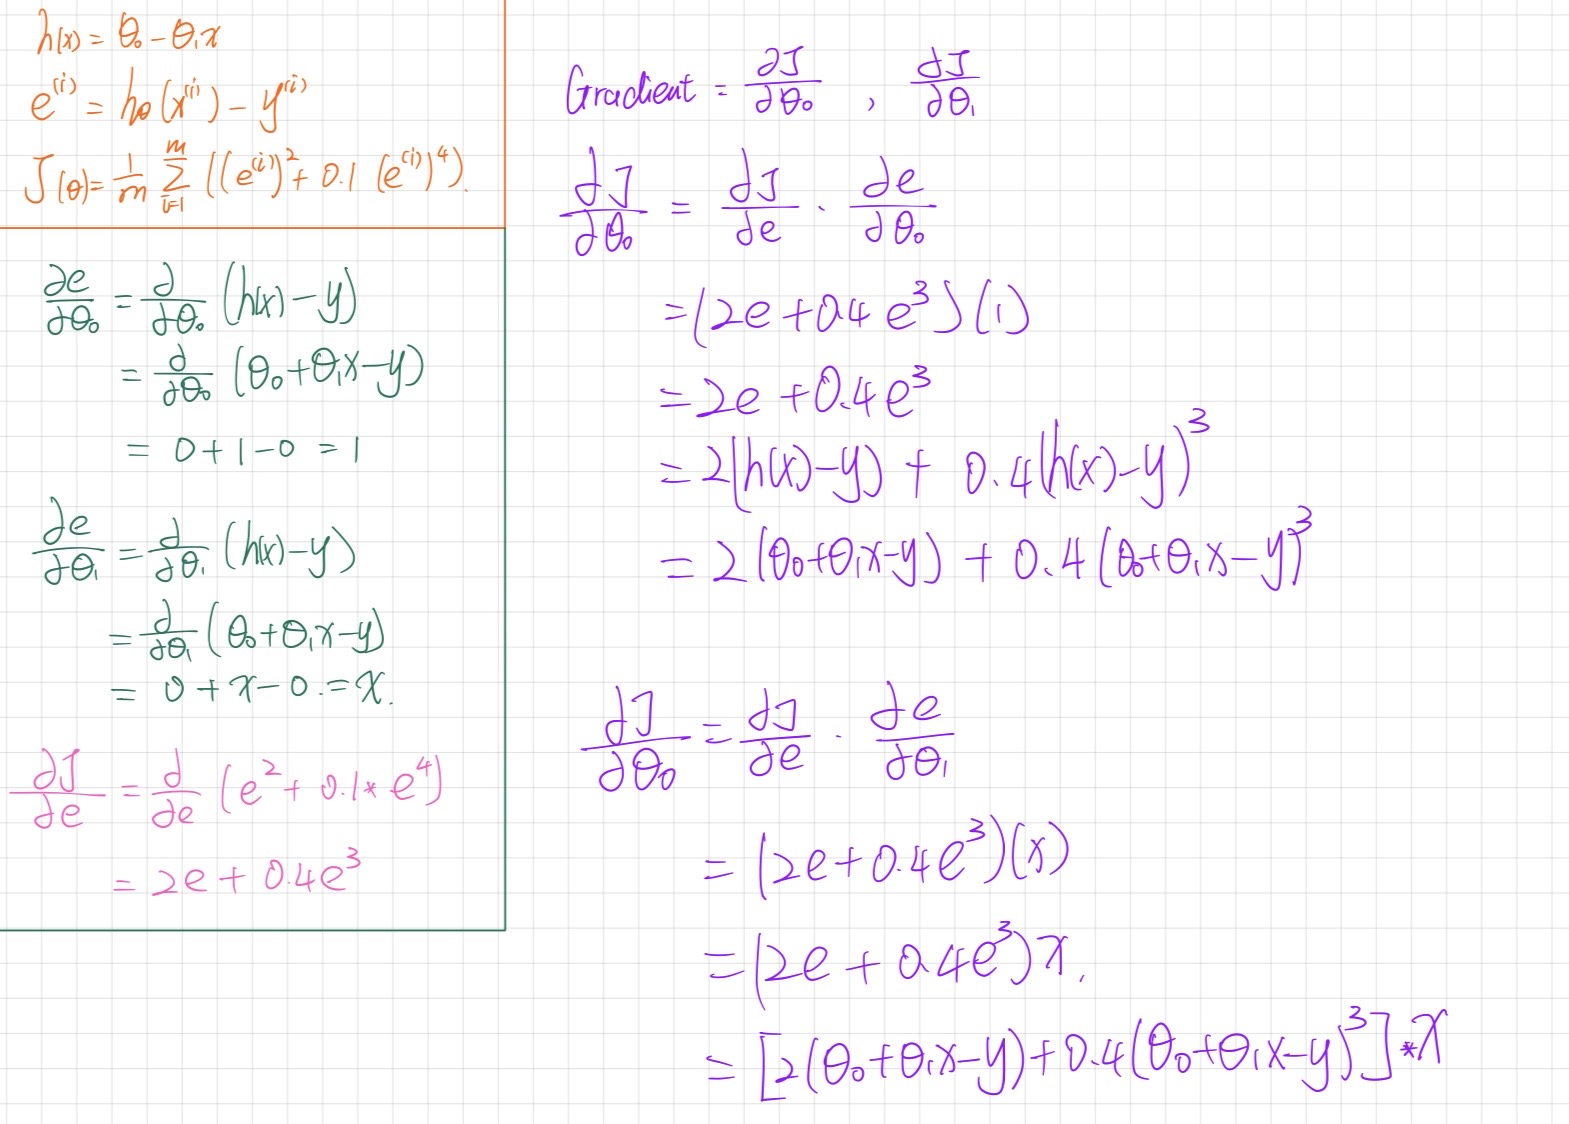

In [175]:
#
# Gradient function based on the cost function J(theta)
# this is the derivative of the cost Function delta(J)/delta(e)
#
# SIGNATURES:
# data_df: data set recording the year and related vehicles price of min and max
# price_col: the name of the price column in data_df
# year_col: the name of the year column in data_df
# theta0: the value of theta 0 of linear regression
# theta1: the value of theta 1 of linear regression
#
# return: a tuple store the value of gradient theta 0 and gradient theta 1
#
def gradient(data_df, price_col, year_col, theta0, theta1):
  my_years = data_df[year_col]
  my_price = data_df[price_col]

  grad_theta0 = 0
  grad_theta1 = 0
  for i in range(len(my_years)):
    year = my_years.iloc[i]

    actual_price = my_price.iloc[i]
    prediction = linear_regression(year,theta0=theta0,theta1=theta1)
    error = prediction - actual_price
    grad_theta0 += (2*error + 0.4*error**3)
    grad_theta1 += (2*error + 0.4*error**3)*year
  return (grad_theta0/len(my_years), grad_theta1/len(my_years))


Here is the gradient descent formula based on the gradient

In [176]:
# Function to calculate the gradient descent
# the main formula is new_theta = old_theta - Alpha * gradient(theta)
#
# SIGNATURES:
# data_df: data set recording the year and related vehicles price of min and max
# price_col: the name of the price column in data_df
# year_col: the name of the year column in data_df
# theta0: the value of theta 0 of linear regression
# theta1: the value of theta 1 of linear regression
# alpha: learning rate
#
# return: returns a tuple of new theta 0 and new theta 1
#
def gradient_descent(data_df, price_col, year_col, theta0, theta1, alpha):
  grad_theta0, grad_theta1 = gradient(data_df, price_col, year_col, theta0, theta1)
  new_theta0 = theta0 - alpha*grad_theta0
  new_theta1 = theta1 - alpha*grad_theta1
  return (new_theta0, new_theta1)



## Learning Test

Here is the test of updating the theta 1 time because the cost function is exponent so I just want to see what the update value of theta and cost are when I initial the theta value as (0,0)

In [177]:
init_theta0 = 0
init_theta1 = 0

init_predict = linear_regression(years[0], theta0=init_theta0, theta1=init_theta1)
init_grad_theta0, init_grad_theta1 = gradient(data_df, 'min Price', 'year', init_theta0, init_theta1)
init_cost = cost_func(data_df, 'min Price', 'year', init_theta0, init_theta1)

print(f"start prediction: {init_predict}")
print(f"start gradient of theta 0: {init_grad_theta0}")
print(f"start gradient of theta 1: {init_grad_theta1}")
print(f"start cost function: {init_cost}")
#


start prediction: 0
start gradient of theta 0: -4257003258466.364
start gradient of theta 1: -8600508450284192.0
start cost function: 2.907286085483342e+16


In [178]:
test_alpha = 0.0001
test_new_theta0, test_new_theta1 = gradient_descent(data_df, 'min Price', 'year', init_theta0, init_theta1, test_alpha)
print(f"test new theta 0: {test_new_theta0}")
print(f"test new theta 1: {test_new_theta1}")
new_predict = linear_regression(years[0], theta0=test_new_theta0, theta1=test_new_theta1)
print(f"test new prediction: {new_predict}")

test new theta 0: 425700325.8466364
test new theta 1: 860050845028.4192
test new prediction: 1742463437727903.0


Here since the cost function is exponential, even I give the 0.0001 as the learning rate the theta value and the prediction is still too big, in this case I need to provide a smaller value for learning rate

# Traditional Learning

The regular learning with the fixed value of learning rate and original value of feature(years)

The output here are stored into the list given into the signatures showing below those output signature are used to store the values instead of return all them.

In [179]:
# learning algorithm used to doing the gradient descent to update the weight(theta)
#
# SIGNITURES INPUT:
# learning_rate: (float type) learning rate(alpha) of the update function
# iteration_num: (Integer type) num of iteration
# theta: (a tuple) store the theta 0 and theta 1
# data_df: the panda data frame that stores the years, min price, and max price
# price_col: (String type) a name of the price column of data frame (min price / max price)
# year_col: (String type) a name of the feature column(year) of panda data frame
#
# SIGNITURES OUTPUT:
# predicct_list: 2-d array to store the hyphothesis result h(x) for every iteration
# theta0_list: a list to store the update value of theta 0 for every iteration
# cost_list: a list to store
#
# Return: void
#
def learning(learning_rate, iteration_num, theta, data_df, price_col, year_col,
             predicts_list, theta0_list, theta1_list, cost_list):
  new_theta0, new_theta1 = theta
  for i in range(iteration_num):
    new_theta0, new_theta1 = gradient_descent(data_df, price_col, year_col, new_theta0, new_theta1, learning_rate)
    theta0_list.append(new_theta0)
    theta1_list.append(new_theta1)


    cost = cost_func(data_df, price_col, year_col, new_theta0, new_theta1)
    cost_list.append(cost)

    predict_list = []
    for j in range(len(years)):
      predict_list.append(linear_regression(years[j], theta0=new_theta0, theta1=new_theta1))
    predicts_list.append(predict_list)

# prepare the value of learning rate(alpha) and the iteration number of how many time it should learning
alpha = 1e-16
iteration_num = 100


##Minimum Modeling

Here is how I build the Model of Minimum price of the vehicles

In [180]:

min_theta = (0,0)
min_hypothesis_list = []
min_theta0_list = [min_theta[0]]
min_theta1_list = [min_theta[1]]
min_cost_list = []

learning(alpha, iteration_num, min_theta, data_df, 'min Price', 'year',
         min_hypothesis_list, min_theta0_list, min_theta1_list, min_cost_list)

# get the last iteration result of prediciton for the min price
min_final_hypothesis = min_hypothesis_list[len(min_hypothesis_list)-1]
# get the last iteration result of theta 0
min_final_theta0 = min_theta0_list[len(min_theta0_list)-1]
# get the last iteration result of theta 1
min_final_theta1 = min_theta1_list[len(min_theta1_list)-1]
# a list to store the error of prediction from the last iteration
min_final_error = []

# calculate the error and store the error into the min_final_error list
for i in range(len(years)):
  min_final_error.append(round((min_final_hypothesis[i] - minPrice[i]),2))

print(f"final modeling result (linear regression result):"+
      f" h(x) = {round(min_final_theta0,5)} + {round(min_final_theta1,5)} * x")
print(f"value of cost function of last prediction: {round(min_cost_list[len(min_cost_list)-1],5)}")

# build the data frame to see the performance of my prediciton
min_result_df = pd.DataFrame({
    "Years":years,
    "Min Price":minPrice,
    "Predicts":min_final_hypothesis,
    "Error":min_final_error,
})

display((min_result_df))

final modeling result (linear regression result): h(x) = 0.00496 + 10.04571 * x
value of cost function of last prediction: 544708182093170.06


,Years,Min Price,Predicts,Error
0,2026,33550,20352.611642,-13197.39
1,2025,33550,20342.565933,-13207.43
2,2024,32820,20332.520224,-12487.48
3,2023,27400,20322.474514,-7077.53
4,2022,25980,20312.428805,-5667.57
5,2021,24820,20302.383096,-4517.62
6,2020,24110,20292.337387,-3817.66
7,2019,24000,20282.291678,-3717.71
8,2011,18160,20201.926005,2041.93
9,2010,17820,20191.880296,2371.88


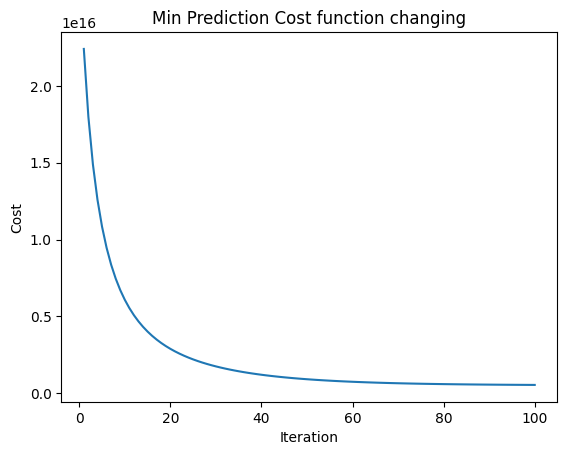

In [181]:
#
# draw the figure of cost function to see how does the
# cost value changed during the 100 iterations
#
plt.plot(range(1, iteration_num + 1), min_cost_list)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Min Prediction Cost function changing")

plt.show()

we can see here the Cost curve shows the value has converge at the end of the iteration and the final theta numbers for the minimum price are:
1.  theta 0 = 0.00496
2.  theta 1 = 10.04571

However, prediction errors shown in data frame are still big


### Prediction of minimum price from 2012 to 2018
Here is the prediction of the minimum price of vehicles from year 2012 to 2018

Here I just shows the plot from 2012 to 2018 the final plot integrate with all data are shown at the end of this Part

In [182]:
predict_years = [2012,2013,2014,2015,2016,2017,2018]

# a list to store the prediction price of the minimum value
min_price_predict = []
# doing the prediction based on the model
for year in predict_years:
  min_price_predict.append(linear_regression(year, theta0=min_final_theta0, theta1=min_final_theta1))

# build the data frame to see the result of prediction
predict_min_df = pd.DataFrame({
    "Years":predict_years,
    "Predicts":min_price_predict
})
display(predict_min_df)

,Years,Predicts
0,2012,20211.971714
1,2013,20222.017423
2,2014,20232.063132
3,2015,20242.108841
4,2016,20252.154551
5,2017,20262.200260
6,2018,20272.245969


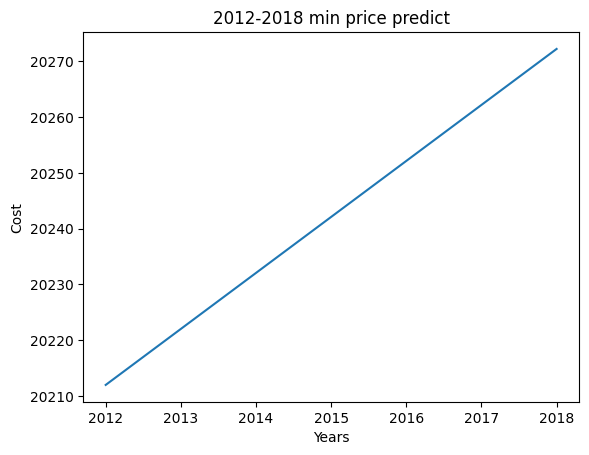

In [183]:
# build the plot to see of the price changed based on the year
plt.plot(range(2012, 2019), min_price_predict)

plt.xlabel("Years")
plt.ylabel("Cost")
plt.title("2012-2018 min price predict")

plt.show()

## Max Modeling

Here is how I build the Model to predict the maximum price of the vehicles based on the learning data

In [184]:
max_theta = (0,0)
max_hypothesis_list = []
max_theta0_list = [max_theta[0]]
max_theta1_list = [max_theta[1]]
max_cost_list = []

# doing the learning to update the maximum modeling
learning(alpha, iteration_num, max_theta, data_df, 'max Price', 'year', max_hypothesis_list, max_theta0_list, max_theta1_list, max_cost_list)
# get the last iteration result of prediciton for the max price
max_final_hypothesis = max_hypothesis_list[len(max_hypothesis_list)-1]
# get the last iteration result of the theta0
max_final_theta0 = max_theta0_list[len(max_theta0_list)-1]
# get the last iteration result of the theta1
max_final_theta1 = max_theta1_list[len(max_theta1_list)-1]
# a list to store the errors of prediction from the max_final_hypothesis
max_final_error = []

# calculate the error and store the error into the max_final_error list
for i in range(len(years)):
  max_final_error.append(round((max_final_hypothesis[i] - maxPrice[i]),2))

print(f"final modeling result (linear regression result):"+
      f" h(x) = {round(max_final_theta0,5)} + {round(max_final_theta1,5)} * x")
print(f"value of cost function of last prediction: {round(max_cost_list[len(max_cost_list)-1],5)}")
# build the data frame to see the performance of my prediciton
max_result_df = pd.DataFrame({
    "Years":years,
    "Max Price":maxPrice,
    "Predicts":max_final_hypothesis,
    "Error":max_final_error,
})

display((max_result_df))


final modeling result (linear regression result): h(x) = 0.0088 + 17.8791 * x
value of cost function of last prediction: 3777515622392022.5


,Years,Max Price,Predicts,Error
0,2026,57270,36223.056590,-21046.94
1,2025,56070,36205.177495,-19864.82
2,2024,55720,36187.298399,-19532.70
3,2023,40945,36169.419304,-4775.58
4,2022,39730,36151.540208,-3578.46
5,2021,39035,36133.661112,-2901.34
6,2020,38675,36115.782017,-2559.22
7,2019,38565,36097.902921,-2467.10
8,2011,26070,35954.870156,9884.87
9,2010,25800,35936.991060,10136.99


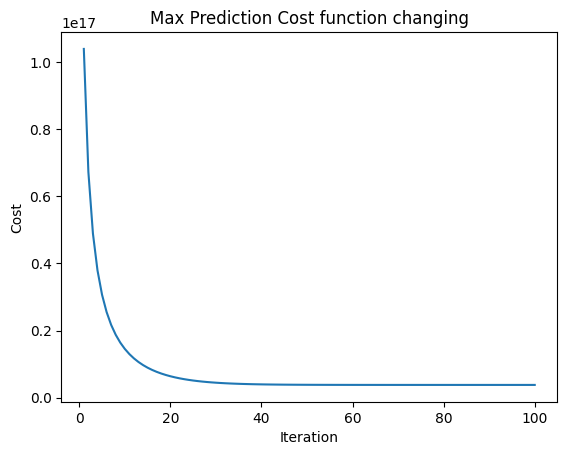

In [185]:
#
# draw the figure of cost function to see how does the
# cost value changed during the 100 iterations
#
plt.plot(range(1, iteration_num + 1), max_cost_list)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Max Prediction Cost function changing")

plt.show()

The cost value during the iteration seems also convergence at the end of the iteration, which is what we want, and the theta value for the maximum price are:


1.   theta 0 = 0.0088
2.   theta 1 = 17.8791



### Prediction of maximum price from 2012 to 2018

Here is how I do the prediction of max price of vehicles from the year 2012 to 2018

In [186]:
# a list to store the prediction result
max_price_predict = []
# prediction process based on the result of theta 0 and theta 1 from learning last iteration
for year in predict_years:
  max_price_predict.append(linear_regression(year, theta0=max_final_theta0, theta1=max_final_theta1))

# build the data frame to see the result of prediction
predict_min_df = pd.DataFrame({
    "Years":predict_years,
    "Predicts":max_price_predict
})
display(predict_min_df)


,Years,Predicts
0,2012,35972.749251
1,2013,35990.628347
2,2014,36008.507443
3,2015,36026.386538
4,2016,36044.265634
5,2017,36062.144730
6,2018,36080.023825


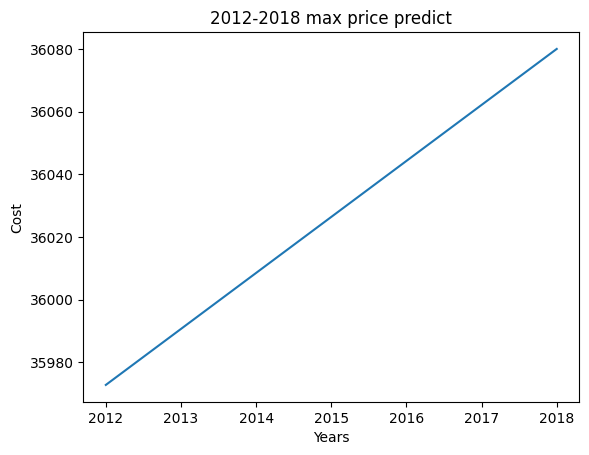

In [187]:
# draw the plot to see how does the prediciton of max price change
plt.plot(range(2012, 2019), max_price_predict)

plt.xlabel("Years")
plt.ylabel("Cost")
plt.title("2012-2018 max price predict")

plt.show()

### Year-to-Price Curves with predicted values for missing years

In [188]:
predict_df = pd.DataFrame({
    "year": predict_years,
    "min Price": min_price_predict,
    "max Price": max_price_predict
})
# add the prediction into the original frame
new_data_df = pd.concat(
    [data_df[["year", "min Price", "max Price"]], predict_df],
    ignore_index=True
)

new_data_df = new_data_df.sort_values(
    by="year"
).reset_index(drop=True)

display(new_data_df)

,year,min Price,max Price
0,1998,11485.000000,19695.000000
1,1999,11845.000000,19435.000000
2,2000,11580.000000,19785.000000
3,2001,11960.000000,24335.000000
4,2002,12565.000000,25010.000000
5,2003,13645.000000,25450.000000
6,2004,14575.000000,26015.000000
7,2005,14610.000000,26795.000000
8,2006,14450.000000,26670.000000
9,2007,13970.000000,24425.000000


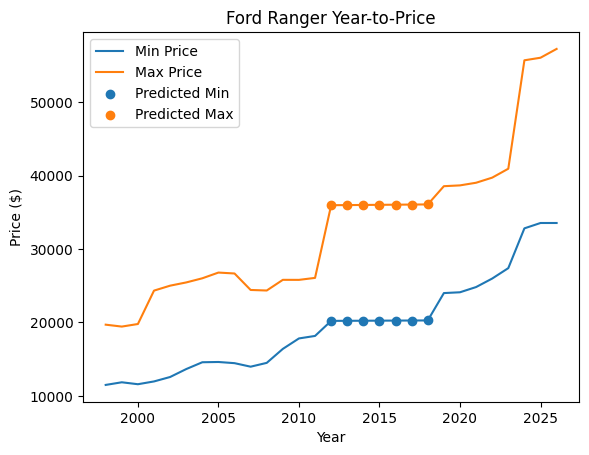

In [189]:
plt.plot(
    new_data_df["year"],
    new_data_df["min Price"],
    label="Min Price"
)

plt.plot(
    new_data_df["year"],
    new_data_df["max Price"],
    label="Max Price"
)


plt.scatter(
    predict_years,
    min_price_predict,
    label="Predicted Min"
)

plt.scatter(
    predict_years,
    max_price_predict,
    label="Predicted Max"
)

plt.xlabel("Year")
plt.ylabel("Price ($)")
plt.title("Ford Ranger Year-to-Price")
plt.legend()
plt.show()

The part marked by points are the part that I predict based on the Model Theta, and we can see here it is kind flat.

# Feature Scaling

Here is the modeling with feature scaling and dynamic learning rate

In [190]:
# a function to scale the feature(years) from the data sets
#
# here are two type of the scaling:
# type(1) (x-miu)/standard deviation
# type(2) (x-miu)/Range of value
#
# SIGNATURES:
# features: feature of data set (years in this case)
# scaling_type: the type of the scaling:
#   1) (int) 1 represent type-1
#   2) (int) 2 represent type-2
#   3) others raise the exception
#
# Returns: a list of scaling freatures
#
def feature_scaling(features, scaling_type):
  result = []
  miu = np.mean(features)

  match scaling_type:
    case 1:
      for feature in features:
        result.append((feature - miu)/np.std(features))
    case 2:
      max_value = np.max(features)
      min_value = np.min(features)
      for feature in features:
        result.append((feature - miu)/(max_value - min_value))
    case _:
      raise Exception("Invalid scaling type there are two type (1 or 2)")
  return result



Here I just joint the scaling value into the data set for doing the modeling later

In [191]:
# scaling feature with the type 1
scaling_result1 = feature_scaling(years, 1)
# scaling feature with the type 2
scaling_result2 = feature_scaling(years, 2)

# join the scaling features into the data set
data_df['scaling1'] = scaling_result1
data_df['scaling2'] = scaling_result2
# check the data set
display(data_df)

,year,min Price,max Price,scaling1,scaling2
0,2026,33550,57270,1.601224,0.534091
1,2025,33550,56070,1.494152,0.498377
2,2024,32820,55720,1.387079,0.462662
3,2023,27400,40945,1.280006,0.426948
4,2022,25980,39730,1.172933,0.391234
5,2021,24820,39035,1.065861,0.355519
6,2020,24110,38675,0.958788,0.319805
7,2019,24000,38565,0.851715,0.284091
8,2011,18160,26070,-0.004867,-0.001623
9,2010,17820,25800,-0.111940,-0.037338


In [192]:
# a function to calculate how the learning rate changed based on
# the current iteration number
# Formular: new alpha = old alpha * (constant / (constant + tau))
# (where the tau is the current iteration number)
#
# SIGNATURES:
# learning rate: the initial value of the learning rate
# iteration_num: current number of iteration
# constant: a constant number in dynamic learning rate formular
#
# returns: a float value
#
def dynamic_Learning_rate(learning_rate, iteration_num, constant):
  new_alpha = learning_rate*(constant/(constant+iteration_num))
  return new_alpha

# dynamic learning algorithm used to doing the gradient descent
# with dynamic learning rate to update the weight(theta)
#
# SIGNITURES INPUT:
# learning_rate: (float type) learning rate(alpha) of the update function
# data_df: the panda data frame that stores the years, min price, and max price
# iteration_num: (Integer type) num of iteration
# theta: (a tuple) store the initial theta 0 and theta 1
# constant: a constant number to calculate the dynamic learning rate
# price_col: (String type) a name of the column name of the panda data frame (min price / max price)
# year_col: name of the of data_df
#
# SIGNITURES OUTPUT:
# alpha_list: a list to store the update value of alpha for every iteration
# predicts_list: 2-d array to store the hyphothesis result h(x) for every iteration
# theta0_list: a list to store the update value of theta 0 for every iteration
# theta1_list: a list to store the update value of theta 1 for every iteration
# cost_list: a list to store the value of cost function
#
# Return: void
def dynamic_learning(learning_rate, data_df, iteration_num, theta, constant, price_col, year_col,
            alpha_list, predicts_list, theta0_list, theta1_list, cost_list):
  new_theta0, new_theta1 = theta
  new_alpha = learning_rate
  for i in range(iteration_num):
    new_alpha = dynamic_Learning_rate(learning_rate, i, constant)
    alpha_list.append(new_alpha)
    new_theta0, new_theta1 = gradient_descent(data_df, price_col, year_col, new_theta0, new_theta1, new_alpha)
    theta0_list.append(new_theta0)
    theta1_list.append(new_theta1)


    cost = cost_func(data_df, price_col, year_col, new_theta0, new_theta1)
    cost_list.append(cost)

    features = data_df[year_col]
    predict_list = []
    for j in range(len(years)):
      predict_list.append(linear_regression(features[j], theta0=new_theta0, theta1=new_theta1))
    predicts_list.append(predict_list)

# define the initial value of learning rate
learning_rate = 2e-9
# define the value of iteration number
iteration_num = 100
# define the initial value of theta
theta = (0,0)
# define the value of constant c for dynamic learning rate
constant = 10
# define the type of scaling that I use
year_col1 = 'scaling1'


## minimum modeling for feature scaling 1

I implemented two feature-scaling methods, but I used the first method, standardization for the scaled models

(x-miu)/standard deviation,

In [193]:
# column name of data_df
min_price_col = 'min Price'
min_alpha_list = []
min_hypothesis_list1 = []
min_theta0_list1 = [theta[0]]
min_theta1_list1 = [theta[1]]
min_cost_list1 = []

# learning
dynamic_learning(learning_rate, data_df, iteration_num, theta, constant, min_price_col, year_col1,
            min_alpha_list, min_hypothesis_list1, min_theta0_list1, min_theta1_list1, min_cost_list1)

# a list to store the values of the learning rate during the iteration
min_final_hypothesis1 = min_hypothesis_list1[len(min_hypothesis_list1)-1]
# the value of theta 0 from the last iteration
min_final_theta01 = min_theta0_list1[len(min_theta0_list1)-1]
# the value of theta 1 from the last iteration
min_final_theta11 = min_theta1_list1[len(min_theta1_list1)-1]
# a list to store the error from the prediction min_final_hypothesis1
min_final_error1 = []


# calculate the error and store the error into the min_final_error list
for i in range(len(years)):
  min_final_error1.append(round((min_final_hypothesis1[i] - minPrice[i]),5))

print(f"final modeling result (linear regression result):"+
      f" h(x) = {round(min_final_theta01,5)} + {round(min_final_theta11,5)} * x")
print(f"value of cost function of last prediction: {round(min_cost_list1[len(min_cost_list1)-1],5)}")

# build the data frame to see the performance of my prediciton
min_result_df1 = pd.DataFrame({
    "Years":years,
    "Min Price":minPrice,
    "Predicts":min_final_hypothesis1,
    "Error":min_final_error1,
})

display((min_result_df1))




final modeling result (linear regression result): h(x) = 15209.70501 + 7532.72664 * x
value of cost function of last prediction: 65323174689302.125


,Years,Min Price,Predicts,Error
0,2026,33550,27271.291092,-6278.70891
1,2025,33550,26464.741263,-7085.25874
2,2024,32820,25658.191433,-7161.80857
3,2023,27400,24851.641604,-2548.35840
4,2022,25980,24045.091774,-1934.90823
5,2021,24820,23238.541945,-1581.45806
6,2020,24110,22431.992115,-1678.00788
7,2019,24000,21625.442286,-2374.55771
8,2011,18160,15173.043650,-2986.95635
9,2010,17820,14366.493821,-3453.50618


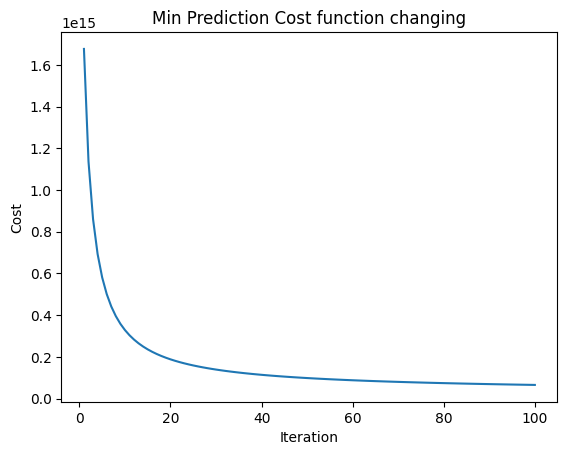

In [194]:
#
# draw the figure of cost function to see how does the
# cost value changed during the 100 iterations
#
plt.plot(range(1, iteration_num + 1), min_cost_list1)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Min Prediction Cost function changing")

plt.show()

The final theta are:


1.   theta 0 = 15209.70501
2.   theta 1 = 7532.72664


The loss curves shows convergence as well, but here we can see there does some improvement the loss curve from traditional Model (the model without scaling years) are start with exponent 16, but here the scaling model loss curves start with the exponent 15 and the value of cost function at the last iteration is 65323174689302.125 which is smaller than the last one (544708182093170.06)

### Prediction value of minimum price from 2012-2018

Year-to-Price plot also shown at the end of this part

Here I also need to Scaling the years value from 2012 to 2018 to predict, and I cannot just direct use the scaling function I provide above because if I do so, the features will be centered around from 2012 to 2018, but the real center should be from 1998 to 2026

In [195]:
# a list to store the prediction value of minimum price
min_price_predict1 = []
# a list of scaling value for the predictioin features
train_mean = np.mean(years)
train_std = np.std(years)
scaling_years1 = []
for year in predict_years:
  scaling_years1.append((year - train_mean)/train_std)

# process of prediction
for year in scaling_years1:
  min_price_predict1.append(linear_regression(year, theta0=min_final_theta01, theta1=min_final_theta11))

# build the data frame of the prediciton result
predict_min_df = pd.DataFrame({
    "Years":predict_years,
    "Predicts":min_price_predict1
})

display(predict_min_df)




,Years,Predicts
0,2012,15979.593480
1,2013,16786.143309
2,2014,17592.693138
3,2015,18399.242968
4,2016,19205.792797
5,2017,20012.342627
6,2018,20818.892456


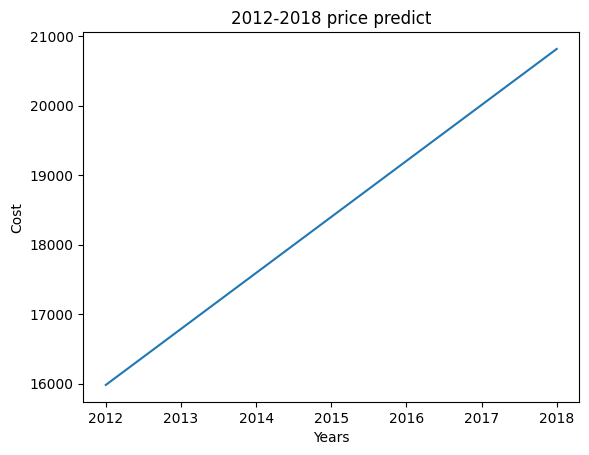

In [196]:
# draw the picture of prediction to see how the price changes
plt.plot(range(2012, 2019), min_price_predict1)

plt.xlabel("Years")
plt.ylabel("Cost")
plt.title("2012-2018 price predict")

plt.show()

## Maximum modeling

In [197]:
# max
max_price_col = 'max Price'
max_alpha_list = []
max_hypothesis_list1 = []
max_theta0_list1 = [theta[0]]
max_theta1_list1 = [theta[1]]
max_cost_list1 = []

# learning
dynamic_learning(learning_rate, data_df, iteration_num, theta, constant, max_price_col, year_col1,
            max_alpha_list, max_hypothesis_list1, max_theta0_list1, max_theta1_list1, max_cost_list1)

# a list to store the values of the learning rate during the iteration
max_final_hypothesis1 = max_hypothesis_list1[len(max_hypothesis_list1)-1]
# the value of theta 0 from the last iteration
max_final_theta01 = max_theta0_list1[len(max_theta0_list1)-1]
# the value of theta 1 from the last iteration
max_final_theta11 = max_theta1_list1[len(max_theta1_list1)-1]
# a list to store the error from the prediction max_final_hypothesis1
max_final_error1 = []

# calculate the errors of max prediction
for i in range(len(years)):
  max_final_error1.append(round((max_final_hypothesis1[i] - maxPrice[i]),5))

max_result_df1 = pd.DataFrame({
    "Years":years,
    "Max Price":maxPrice,
    "Predicts":max_final_hypothesis1,
    "Error":max_final_error1,
})
print(f"final modeling result (linear regression result):"+
      f" h(x) = {round(max_final_theta01,5)} + {round(max_final_theta11,5)} * x")
print(f"value of cost function of last prediction: {round(max_cost_list1[len(max_cost_list1)-1],5)}")
display((max_result_df1))


final modeling result (linear regression result): h(x) = 30829.5139 + 12457.37851 * x
value of cost function of last prediction: 84481308473387.39


,Years,Max Price,Predicts,Error
0,2026,57270,50776.572983,-6493.42702
1,2025,56070,49442.727087,-6627.27291
2,2024,55720,48108.881191,-7611.11881
3,2023,40945,46775.035294,5830.03529
4,2022,39730,45441.189398,5711.18940
5,2021,39035,44107.343502,5072.34350
6,2020,38675,42773.497606,4098.49761
7,2019,38565,41439.651710,2874.65171
8,2011,26070,30768.884541,4698.88454
9,2010,25800,29435.038645,3635.03865


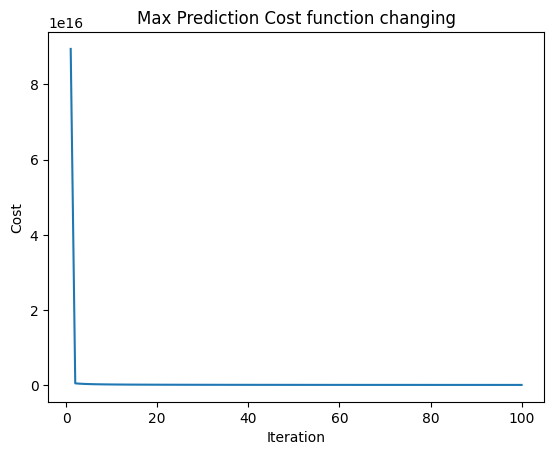

In [198]:
#
# draw the figure of cost function to see how does the
# cost value changed during the 100 iterations
#
plt.plot(range(1, iteration_num + 1), max_cost_list1)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Max Prediction Cost function changing")

plt.show()

Here is the Loss curves of Maximum price is convergence faster than the Traditional Model, and even though the exponent is still start as 16 but the converage is faster and the value of cost function (84481308473387.39) at the last iteration is also much smaller than the Traditional model (3777515622392022.5)

the final value of theta are:


1.   Theta 0 = 30829.5139
2.   Theta 1 = 12457.37851


### Prediction value of Maximum price from 2012 to 2018

In [199]:
max_price_predict1 = []
# scaling_years = feature_scaling(predict_years, 1)

for year in scaling_years1:
  max_price_predict1.append(linear_regression(year, theta0=max_final_theta01, theta1=max_final_theta11))

predict_max_df1 = pd.DataFrame({
    "Years":predict_years,
    "Predicts":max_price_predict1
})
display(predict_max_df1)

,Years,Predicts
0,2012,32102.730437
1,2013,33436.576333
2,2014,34770.422229
3,2015,36104.268126
4,2016,37438.114022
5,2017,38771.959918
6,2018,40105.805814


Text(0.5, 1.0, '2012-2018 max price predict')

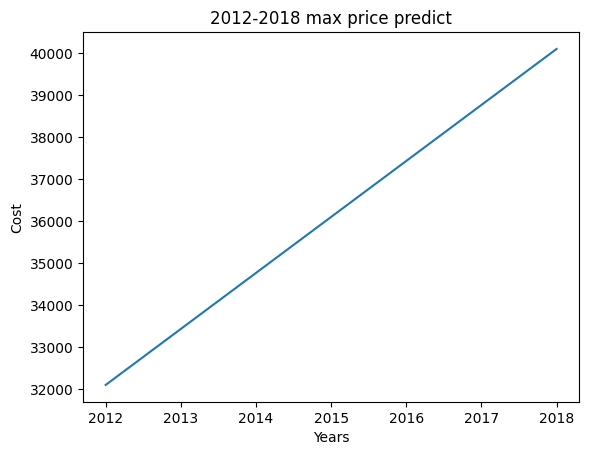

In [200]:
plt.plot(range(2012, 2019), max_price_predict1)

plt.xlabel("Years")
plt.ylabel("Cost")
plt.title("2012-2018 max price predict")

### Year-to-Price Curves with predictied values

In [201]:
predict_df1 = pd.DataFrame({
    "year": predict_years,
    "min Price": min_price_predict1,
    "max Price": max_price_predict1
})
# add the prediction into the original frame
new_data_df1 = pd.concat(
    [data_df[["year", "min Price", "max Price"]], predict_df1],
    ignore_index=True
)

new_data_df1 = new_data_df1.sort_values(
    by="year"
).reset_index(drop=True)

display(new_data_df1)



,year,min Price,max Price
0,1998,11485.000000,19695.000000
1,1999,11845.000000,19435.000000
2,2000,11580.000000,19785.000000
3,2001,11960.000000,24335.000000
4,2002,12565.000000,25010.000000
5,2003,13645.000000,25450.000000
6,2004,14575.000000,26015.000000
7,2005,14610.000000,26795.000000
8,2006,14450.000000,26670.000000
9,2007,13970.000000,24425.000000


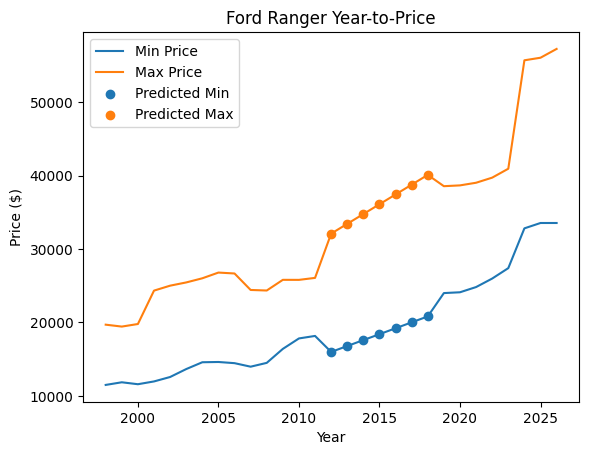

In [202]:
plt.plot(
    new_data_df1["year"],
    new_data_df1["min Price"],
    label="Min Price"
)

plt.plot(
    new_data_df1["year"],
    new_data_df1["max Price"],
    label="Max Price"
)


plt.scatter(
    predict_years,
    min_price_predict1,
    label="Predicted Min"
)

plt.scatter(
    predict_years,
    max_price_predict1,
    label="Predicted Max"
)

plt.xlabel("Year")
plt.ylabel("Price ($)")
plt.title("Ford Ranger Year-to-Price")
plt.legend()
plt.show()

Here is the prediction has a big change, the Prediciton value from Traditional Model seems like flat, but here teh prediciton has a apparent slop  

# Summary
The predicted price range of the 2026 Ford Ranger based on the traditional models is approximately $20,352.61 to $36,223.06. After applying feature scaling and a dynamic learning rate, the predicted price range increases to approximately $27,271.29 to $50,776.57.

Feature scaling and the dynamic learning rate improved the performance of the models. The loss curves converged more effectively, and the final costs were lower than those of the traditional models. However, the prediction errors are still relatively large. For the 2026 Ranger, the scaled minimum-price model has an error of approximately -$6,278.71, while the scaled maximum-price model has an error of approximately -$6,493.43. Therefore, although the scaled models perform better than the traditional models, I do not think they are accurate enough for reliable real-world price prediction.

Based on these results, I would not make a decision to buy the next-generation Ranger based only on the prices predicted by these models, since an error of around $6,000 is significant when evaluating the price of a vehicle. One way to improve the models would be to include additional features instead of using only the model year. For example, vehicle specifications and other factors related to price could potentially help the models make more accurate predictions.



In [209]:
min_predict_2026 = min_final_hypothesis[0]
max_predict_2026 = max_final_hypothesis[0]

min_predict_2026_scaling = min_final_hypothesis1[0]
max_predict_2026_scaling = max_final_hypothesis1[0]

print(f"Tradition predict price range (Year = 2026): {round(min_predict_2026,2)} - {round(max_predict_2026,2)}")
print(f"Scaling predict price range (Year = 2026): {round(min_predict_2026_scaling,2)} - {round(max_predict_2026_scaling,2)}")


Tradition predict price range (Year = 2026): 20352.61 - 36223.06
Scaling predict price range (Year = 2026): 27271.29 - 50776.57


In [203]:
print("Unscaled Min:", min_final_theta0, min_final_theta1)
print("Unscaled Max:", max_final_theta0, max_final_theta1)

print("Scaled Min:", min_final_theta01, min_final_theta11)
print("Scaled Max:", max_final_theta01, max_final_theta11)

predict_compare = pd.DataFrame({
    "Years":predict_years,
    "Min Predicts":min_price_predict,
    "Min Predicts(Scaling)":min_price_predict1,
    "Max Predicts":max_price_predict,
    "Max Predicts(Scaling)":max_price_predict1
})

display(predict_compare)
error_compare = pd.DataFrame({
    "Years":years,
    "Min Error":min_final_error,
    "Min Error(Scaling)":min_final_error1,
    "Max Error":max_final_error,
    "Max Error(Scaling)":max_final_error1
})

display(error_compare)

Unscaled Min: 0.004962842786277082 10.045709120917493
Unscaled Max: 0.008804463625847019 17.879095649565723
Scaled Min: 15209.70500590144 7532.726636790521
Scaled Max: 30829.513900032915 12457.378507421978


,Years,Min Predicts,Min Predicts(Scaling),Max Predicts,Max Predicts(Scaling)
0,2012,20211.971714,15979.593480,35972.749251,32102.730437
1,2013,20222.017423,16786.143309,35990.628347,33436.576333
2,2014,20232.063132,17592.693138,36008.507443,34770.422229
3,2015,20242.108841,18399.242968,36026.386538,36104.268126
4,2016,20252.154551,19205.792797,36044.265634,37438.114022
5,2017,20262.200260,20012.342627,36062.144730,38771.959918
6,2018,20272.245969,20818.892456,36080.023825,40105.805814


,Years,Min Error,Min Error(Scaling),Max Error,Max Error(Scaling)
0,2026,-13197.39,-6278.70891,-21046.94,-6493.42702
1,2025,-13207.43,-7085.25874,-19864.82,-6627.27291
2,2024,-12487.48,-7161.80857,-19532.70,-7611.11881
3,2023,-7077.53,-2548.35840,-4775.58,5830.03529
4,2022,-5667.57,-1934.90823,-3578.46,5711.18940
5,2021,-4517.62,-1581.45806,-2901.34,5072.34350
6,2020,-3817.66,-1678.00788,-2559.22,4098.49761
7,2019,-3717.71,-2374.55771,-2467.10,2874.65171
8,2011,2041.93,-2986.95635,9884.87,4698.88454
9,2010,2371.88,-3453.50618,10136.99,3635.03865
